<a href="https://colab.research.google.com/github/Helen-stack/Replication-of-Empirical-Asset-Pricing-via-Machine-Learning-Method/blob/main/Asset_Pricing_Paper_Replication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Replicate analyses from Epiricial Asset Pricing via Machine Learning (2020) by Gu, Kelly and Xiu
# import libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sklearn as sk
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, mean_absolute_error

In [ ]:
# import equity stocks
import yfinance as yf

# select top 10 US tech stocks by market cap, track their prices for the past 30 years
tickers = ['AAPL', 'MSFT', 'MU', 'AMD', 'INTC', 'CSCO', 'ORCL']
data =yf.download(tickers, start = '1991-06-30', end = '2021-06-30')
print(data.head())

# calculate the log-normal monthly return for each stock
# get price for each stock
prices = data['Close']

# take last available price in each month
prices_m = prices.resample('ME').last()

# calculate moonthly log returns
prices_m_log = np.log(prices_m / prices_m.shift(1))

#print(prices_m_log.head())

# append permno code to each of the ticker
ticker_to_permno = {
    'AAPL': 14593,
    'MSFT': 10107,
    'MU': 53613,
    'AMD': 61241,
    'INTC': 59328,
    'CSCO': 76076,
    'ORCL': 10104
}

prices_m_log = prices_m_log.rename(columns = ticker_to_permno)



In [ ]:
print(prices_m_log.head(200))

Summary of experiments done by the study:" We conduct a large-scale empirical analysis, investigating nearly 30,000 individual stocks over 60 years from 1957 to 2016. Our predictor set includes 94 characteristics for each stock, interactions of each characteristic with eight aggregate time-series variables, and 74 industry sector dummy variables, totaling more than 900 baseline signals. Some of our methods expand this predictor set much further by including nonlinear transformations and interactions of the baseline signals. We establish the following empirical facts about machine learning for return prediction."

In [ ]:
# load the 94 characters using pre-built datasets provided by Dacheng Xiu
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/datashare.csv'

# check the columns of the imported dataset
header = pd.read_csv(path, nrows = 0)
all_cols = header.columns.tolist()
print(f"Found {len(all_cols)} columns.")
print(all_cols[:10], "...") # all columns detected

# there are three columns not for characteristics:
id_cols = [c for c in ["permno", "DATE", "sic2"] if c in all_cols]
char_cols = [c for c in all_cols if c not in id_cols]
print(f"{len(char_cols)} characteristic columns detected.")

# select specific columns so not entire datasets get imported, to save RAM space

# Build a dtype map: float32 for characteristics (halves memory vs.
# the pandas default float64), smaller ints for the id columns.
dtype_map = {c: "float32" for c in char_cols}
if "permno" in all_cols:
    dtype_map["permno"] = "int32"
if "sic2" in all_cols:
    dtype_map["sic2"] = "float32"  # has NaNs for some firm-months, so not int

# ----------------------------------------------------------------------
# 3) Load the full file with those dtypes, parsing DATE separately
#    since it's usually stored as an int like 19570329 (YYYYMMDD).
# ----------------------------------------------------------------------

# filter dates in last 30 years
START, END = pd.Timestamp("1991-06-30"), pd.Timestamp("2021-06-30")
PERMNOS = [14593, 10107, 53613, 61241, 59328, 76076, 10104]

chunks = []
for chunk in pd.read_csv(path, dtype = dtype_map, chunksize=500_000):
  chunk['DATE']=pd.to_datetime(chunk['DATE'],format="%Y%m%d")
  chunk = chunk[(chunk['DATE']>=START) & (chunk['DATE']<=END) & (chunk['permno'].isin(PERMNOS))]
  if not chunk.empty:
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['DATE'].min()} to {df['DATE'].max()}")


Mounted at /content/drive
Found 97 columns.
['permno', 'DATE', 'mvel1', 'beta', 'betasq', 'chmom', 'dolvol', 'idiovol', 'indmom', 'mom1m'] ...
94 characteristic columns detected.
Loaded 2,520 rows x 97 columns
Date range: 1991-07-31 00:00:00 to 2021-06-30 00:00:00


In [ ]:
# check for NAs:
na_cols = df.columns[df.isna().any()]
df[na_cols] = df[na_cols].bfill()
df[na_cols] = df[na_cols].ffill()
df[na_cols].isna().sum()


In [ ]:
# split sample into training (30%), testing (50%) and validation set (20%)
# first 9 years as training set:
return_train = prices_m_log.iloc[1:180]
# next 6 years as validation set:
# return_valid = prices_m_log.iloc[109:180]
# final 15 years as testing set:
return_test = prices_m_log.iloc[180:360]
#print(return_train.head())
#print(return_valid.head())
print(return_test.head())
# print(return_train.tail())


Ticker         14593     61241     76076     59328     10107     53613  \
Date                                                                     
2006-07-31  0.171143 -0.230645 -0.088269 -0.054068  0.032097  0.034587   
2006-08-31 -0.001621  0.253718  0.206905  0.089327  0.069616  0.102920   
2006-09-30  0.126247 -0.005618  0.044036  0.049836  0.062225  0.006921   
2006-10-31  0.051890 -0.155560  0.048832  0.036750  0.048529 -0.185776   
2006-11-30  0.122650  0.014006  0.109042  0.007655  0.025801  0.010327   

Ticker         10104  
Date                  
2006-07-31  0.032589  
2006-08-31  0.045062  
2006-09-30  0.124712  
2006-10-31  0.040326  
2006-11-30  0.030919  


Current 3-month Treasury-bill rate is 3.83%, which is used to proxy for the risk-free rate from which we calculate individual excess returns.

We also construct eight macroeconomic predictors following the variable definitions detailed in Welch and Goyal (2008), including dividend-price ratio (dp), earnings-price ratio (ep), book-to-market ratio (bm), net equity expansion (ntis), Treasury-bill rate (tbl), term spread (tms), default spread (dfy), and stock variance (svar).

t in our model is defined by month

We begin our model description with the least complex method in our analysis, the simple linear predictive regression model estimated via ordinary least squares (OLS). Although we expect this to perform poorly in our high dimension problem,

In [ ]:
model = LinearRegression()
START_train, END_train = pd.Timestamp("1991-08-30"), pd.Timestamp("2006-06-30")
START_test, END_test = pd.Timestamp("2006-07-30"), pd.Timestamp("2021-06-30")

# APPL:
X_train_1 = df[(df['DATE']>= START_train) & (df['DATE'] <= END_train) & (df['permno'] == 14593)]
# print(X_train_1.head())
y_train_1 = return_train[14593]
# print(y_train_1.head())

In [ ]:
#print(return_test.tail())
print(y_train_1.tail())

Date
2006-02-28   -0.097577
2006-03-31   -0.088007
2006-04-30    0.115371
2006-05-31   -0.163547
2006-06-30   -0.042727
Freq: ME, Name: 14593, dtype: float64


In [ ]:
# use weighted OLS to make predictions, calculate the out of sample R^2
model = LinearRegression()
START_train, END_train = pd.Timestamp("1991-08-30"), pd.Timestamp("2006-06-30")
START_test, END_test = pd.Timestamp("2006-07-30"), pd.Timestamp("2021-06-30")

# APPL:
# X_train_1 = df[(df['DATE']>= START_train) & (df['DATE'] <= END_train) & (df['permno'] == 14593)][char_cols]
# print(X_train_1.head())
# y_train_1 = return_train[14593]
# print(y_train_1.head())

#run OLS:
# model.fit(X_train_1, y_train_1)
# y_pred_1 = model.predict(X_train_1)

# compute the R^2 formulae:
def r2_oos(y_true, y_predict):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_predict)
    return 1 - np.sum((y_true - y_predict)**2) / np.sum(y_true**2)

# run OLS on all tickers:
# dictionaries to store results, keyed by permno
X_train = {}
y_train = {}
models = {}
y_pred_train = {}
y_pred_test = {}
# for out-of-sample test:
X_test = {}
y_test = {}

# to compute in sample and out of sample R^2 values:
r2_in = {}
r2_out = {}

for p in PERMNOS:
  X_train[p] = df[(df['DATE']>= START_train) & (df['DATE'] <= END_train) & (df['permno'] == p)][char_cols]
  y_train[p] = return_train[p]

  X_test[p] = df[(df['DATE']>= START_test) & (df['DATE'] <= END_test) & (df['permno'] == p)][char_cols]
  y_test[p] = return_test[p]

  m = LinearRegression()
  m.fit(X_train[p], y_train[p])
  models[p] = m

  # Predictions
  y_pred_train[p] = m.predict(X_train[p])
  y_pred_test[p] = m.predict(X_test[p])

  # R^2 scores
  r2_in[p] = r2_oos(y_true = y_train[p], y_predict = y_pred_train[p])
  r2_out[p] = r2_oos(y_true = y_test[p], y_predict = y_pred_test[p])


In [ ]:
# plot the R2 score:
labels = [str(p) for p in PERMNOS]
in_vals = [r2_in[p] for p in PERMNOS]
out_vals = [r2_out[p] for p in PERMNOS]

x = np.arange(len(PERMNOS))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x - width/2, in_vals, width, label='In-sample R²')
ax.plot(x + width/2, out_vals, width, label='Out-of-sample R²')

ax.set_xlabel('Permno')
ax.set_ylabel('R²')
ax.set_title('In-sample vs Out-of-sample R² by Permno')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

# conclusion: because of the predictors' high dimension nature, the OLS is expected to perform very poorly

The simple linear model is bound to fail in the presence of many predictors. When the number of predictors
 approaches the number of observations
⁠, the linear model becomes inefficient or even inconsistent.

According to original paper, Lasso is better than Ridge and equivalent to Elastic Net. We will also add models with Huber loss, as well as models including interaction terms in this step.

In [ ]:
# use training and testing sets to tune parameters for Lasso, Ridge and Elastic Net
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.model_selection import GridSearchCV

# set tuning parameter ranges and the l1 (Lasso) strength ratio
alphas = np.linspace(0, 20, 50)
l1_ratios = np.linspace(0,1,11)

param_grid = {
    'elasticnet__alpha': alphas,
    'elasticnet__l1_ratio': l1_ratios
}

# create dictionaries to store results
X_train, y_train, X_test, y_test = {}, {}, {}, {}
models = {}
y_pred_train, y_pred_test = {}, {}
r2_in, r2_out = {}, {}
# add in dictionaries for huber loss
huber_in, huber_out = {}, {}
best_params = {}

for p in PERMNOS:
  X_train[p] = df[(df['DATE']>= START_train) & (df['DATE'] <= END_train) & (df['permno'] == p)][char_cols]
  y_train[p] = return_train[p]

  X_test[p] = df[(df['DATE']>= START_test) & (df['DATE'] <= END_test) & (df['permno'] == p)][char_cols]
  y_test[p] = return_test[p]

  # create a pipeline for the interaction terms
  pipe = Pipeline(
    [('interactions', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
     ('scaler', StandardScaler()), # standardise the variables!
     ('elasticnet', ElasticNet(max_iter=10000, random_state = 42))
    ]
  )


  grid = GridSearchCV(
    pipe,
    param_grid = param_grid,
    cv=10,
    scoring='r2',
    n_jobs = -1
   )
  grid.fit(X_train[p], y_train[p])

  m = grid.best_estimator_
  models[p]=m
  best_params[p]= grid.best_params_

  # make predictions
  y_pred_train[p] = m.predict(X_train[p])
  y_pred_test[p] = m.predict(X_test[p])

  # R^2 scores
  r2_in[p] = r2_oos(y_true = y_train[p], y_predict = y_pred_train[p])
  r2_out[p] = r2_oos(y_true = y_test[p], y_predict = y_pred_test[p])

In [ ]:
# plot for Elastic Net R^2:
labels = [str(p) for p in PERMNOS]
in_vals = [r2_in[p] for p in PERMNOS]
out_vals = [r2_out[p] for p in PERMNOS]

x = np.arange(len(PERMNOS))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, in_vals, width, label='In-sample R²')
ax.bar(x + width/2, out_vals, width, label='Out-of-sample R²')

ax.set_xlabel('Tickers')
ax.set_ylabel('R²')
ax.set_title('Elastic Net + Interactions: In-sample vs Out-of-sample R² by Permno')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Repeat above process using Huber Loss as the loss function

In [ ]:
# Use PCR to reduce dimentionality, then fit the model using R^2 as loss function
from sklearn.decomposition import PCA

X_train_pcr, y_train_pcr, X_test_pcr, y_test_pcr = {}, {}, {}, {}
y_pred_train_pcr, y_pred_test_pcr, r2_in_pcr, r2_out_pcr = {}, {}, {}, {}

for p in PERMNOS:
  X_train_pcr[p] = df[(df['DATE']>= START_train) & (df['DATE'] <= END_train) & (df['permno'] == p)][char_cols]
  y_train_pcr[p] = return_train[p]

  X_test_pcr[p] = df[(df['DATE']>= START_test) & (df['DATE'] <= END_test) & (df['permno'] == p)][char_cols]
  y_test_pcr[p] = return_test[p]

  # Since PCR is highly sensitive to standardisation, we need to remember to standardise the variables
  pcr_pipe = Pipeline(
    [
     ('scaler', StandardScaler()), # standardise the variables!
     ('pca', PCA()),
     ('regressor', LinearRegression())
    ]
  )

  param_grid = {"pca__n_components": range(1, df[char_cols].shape[1] + 1)} # maximum is to choose all predictors

  # feed the pipeline into cross validation to pick the optimal number of components
  pcr_grid = GridSearchCV(
    pcr_pipe,
    param_grid = param_grid,
    cv=10,
    scoring='r2',
    n_jobs = -1
   )
  pcr_grid.fit(X_train_pcr[p], y_train_pcr[p])

  # print optimal number of principal components
  best_n_components = pcr_grid.best_params_["pca__n_components"]
  print(f"Optimal number of principal components: {best_n_components}")

  # fit the final model with optimal number of components and print its R score
  best_pcr = pcr_grid.best_estimator_
  # make predictions
  y_pred_train_pcr[p] = best_pcr.predict(X_train_pcr[p])
  y_pred_test_pcr[p] = best_pcr.predict(X_test_pcr[p])

  # R^2 scores
  r2_in_pcr[p] = r2_oos(y_true = y_train_pcr[p], y_predict = y_pred_train_pcr[p])
  r2_out_pcr[p] = r2_oos(y_true = y_test_pcr[p], y_predict = y_pred_test_pcr[p])


Optimal number of principal components: 1
Optimal number of principal components: 1
Optimal number of principal components: 3
Optimal number of principal components: 1
Optimal number of principal components: 1
Optimal number of principal components: 1
Optimal number of principal components: 1


In [ ]:
# use PCR and create charts that show the variance contribution of each predictor
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.base import BaseEstimator, RegressorMixin

# define a function that select and rank all the predictors based on their variance contribution
def pcr_select_rank(X, y, max_components = None, cv_folds=10, random_state=0):
  feature_names = X.columns.to_numpy()
  X_vals = X.values
  n_samples, n_features = X_vals.shape
  if max_components is None:
    max_components = min(n_samples-1, n_features)
  # important to scale the variables
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X_vals)

  y_scaler = StandardScaler()
  y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1))


  kf=KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
  cv_scores = []
  for k in range(1, max_components + 1):
    pca=PCA(n_components=k, random_state=random_state)
    scores = cross_val_score(
      _PCRWrapper(pca, LinearRegression()),
      X_scaled,
      y_scaled,
      cv=kf,
      scoring='neg_mean_squared_error',
      n_jobs=-1
    )
    cv_scores.append(-scores.mean())

  cv_results = pd.DataFrame({
  "n_components": range(1, max_components + 1),
  "cv_score": cv_scores
  })

  optimal_k = int(cv_results.loc[cv_results['cv_score'].idxmin(), 'n_components'])

  # fit PCA with optimal_k and compute importance
  pca_fitted=PCA(n_components=optimal_k, random_state=random_state)
  pca_fitted .fit(X_scaled, y_scaled)

  loadings = pca_fitted.components_.T
  explained_var = pca_fitted.explained_variance_ratio_

  importance_raw = (loadings ** 2) @ explained_var
  importance_pct = 100 * importance_raw / importance_raw.sum()

  importance = pd.DataFrame({
        "predictor": feature_names,
        "importance": importance_raw,
        "importance_pct": importance_pct
  }).sort_values("importance", ascending=False).reset_index(drop=True)

  # add in predicted y values using optimal number of variables
  pcr_pred = LinearRegression()
  pcr_pred.fit(pca_fitted.transform(X_scaled), y_scaled)
  fitted = {"scaler": scaler, "pca": pca_fitted, "reg": pcr_pred}

  return optimal_k, importance, cv_results, fitted

# Predict using the dict returned by pcr_select_and_rank's 4th output.
# X_new: for the new testing set.
def predict_pcr(fitted, X_new):
  X_scaled = fitted["scaler"].transform(X_new.values)
  X_pcs = fitted["pca"].transform(X_scaled)
  return fitted["reg"].predict(X_pcs)

class _PCRWrapper(BaseEstimator, RegressorMixin):
    """Small helper so PCA + LinearRegression can be cross-validated as one estimator."""
    def __init__(self, pca, reg):
        self.pca = pca
        self.reg = reg

    def fit(self, X, y):
        Xt = self.pca.fit_transform(X)
        self.reg.fit(Xt, y)
        return self

    def predict(self, X):
        Xt = self.pca.transform(X)
        return self.reg.predict(Xt)

# create a loop to feed data into the variance rank function
X_train_pcr2, y_train_pcr2, X_test_pcr2, y_test_pcr2 = {}, {}, {}, {}

for p in PERMNOS:
  X_train_pcr2[p] = df[(df['DATE']>= START_train) & (df['DATE'] <= END_train) & (df['permno'] == p)][char_cols]
  y_train_pcr2[p] = return_train[p]

  X_test_pcr2[p] = df[(df['DATE']>= START_test) & (df['DATE'] <= END_test) & (df['permno'] == p)][char_cols]
  y_test_pcr2[p] = return_test[p]

  k_pcr, imp_pcr, cv_pcr, fit_pcr = {}, {}, {}, {}
  k_pcr[p], imp_pcr[p], cv_pcr[p], fit_pcr[p] = pcr_select_rank(X_train_pcr2[p], y_train_pcr2[p])
  print(f"Optimal number of components: {k_pcr[p]}")
  print(imp_pcr[p])

# create a loop to feed data into the prediction function
y_pred_train_pcr2, y_pred_test_pcr2, r2_in_pcr2, r2_out_pcr2 = {}, {}, {}, {}
k_pcr, imp_pcr, cv_pcr, fit_pcr = {}, {}, {}, {}

# make predictions
for p in PERMNOS:
  k_pcr[p], imp_pcr[p], cv_pcr[p], fit_pcr[p] = pcr_select_rank(X_train_pcr2[p], y_train_pcr2[p])
  y_pred_train_pcr2[p] = predict_pcr(fitted = fit_pcr[p], X_new= X_train_pcr2[p])
  y_pred_test_pcr2[p] = predict_pcr(fitted = fit_pcr[p], X_new = X_test_pcr2[p])

# R^2 scores
  r2_in_pcr2[p] = r2_oos(y_true = y_train_pcr2[p], y_predict = y_pred_train_pcr2[p])
  r2_out_pcr2[p] = r2_oos(y_true = y_test_pcr2[p], y_predict = y_pred_test_pcr2[p])




Optimal number of components: 1
     predictor  importance  importance_pct
0        quick    0.008510        4.353479
1           dy    0.008456        4.325949
2     salecash    0.008239        4.215189
3         cash    0.008179        4.184431
4         tang    0.008116        4.152238
..         ...         ...             ...
89      stdacc    0.000005        0.002736
90     convind    0.000000        0.000000
91        divi    0.000000        0.000000
92         sin    0.000000        0.000000
93  securedind    0.000000        0.000000

[94 rows x 3 columns]
Optimal number of components: 24
     predictor    importance  importance_pct
0          lev  1.097446e-02    1.129099e+00
1          age  1.096668e-02    1.128299e+00
2          gma  1.096556e-02    1.128184e+00
3           ms  1.096428e-02    1.128052e+00
4     cashdebt  1.096288e-02    1.127908e+00
..         ...           ...             ...
89          bm  9.904246e-03    1.018991e+00
90   zerotrade  9.177607e-03    9.44

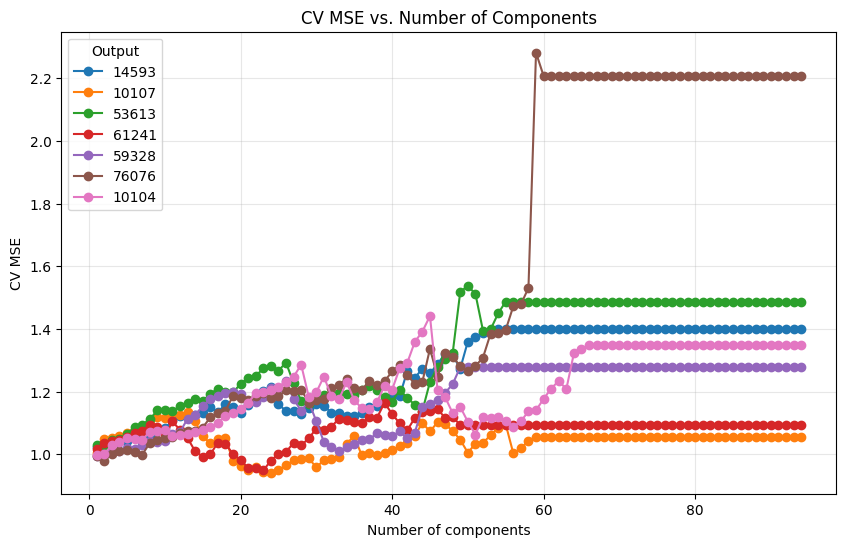

In [ ]:
# plot the CV scores by number of components for each of the permno codes, to check bias-variance tradeoff
fig, ax = plt.subplots(figsize=(10, 6))

for output_name, cv_res in cv_pcr.items():
    ax.plot(cv_res["n_components"], cv_res["cv_score"], marker="o", label=output_name)

ax.set_xlabel("Number of components")
ax.set_ylabel("CV MSE")
ax.set_title("CV MSE vs. Number of Components")
ax.legend(title="Output")
ax.grid(alpha=0.3)
plt.show()

# from the output, we can see the CV MSE stopped decreasing from about 45 predictors onwards for most of the permno codes


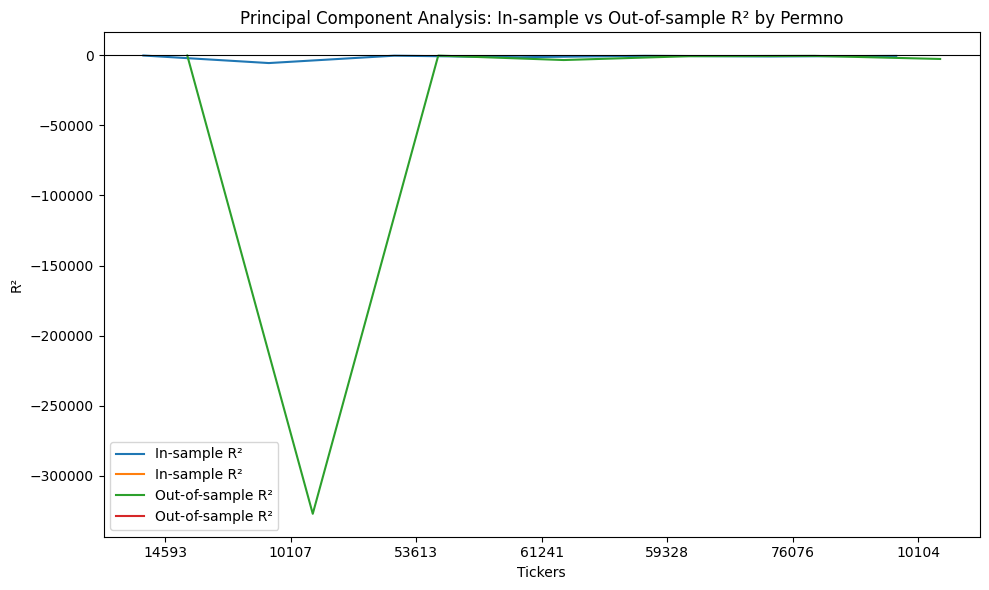

In [ ]:
# now compute and plot the in-sample and out-of-sample R2 for fitted PCA models
labels = [str(p) for p in PERMNOS]
in_vals = [r2_in_pcr2[p] for p in PERMNOS]
out_vals = [r2_out_pcr2[p] for p in PERMNOS]

x = np.arange(len(PERMNOS))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x - width/2, in_vals, width, label='In-sample R²')
ax.plot(x + width/2, out_vals, width, label='Out-of-sample R²')

ax.set_xlabel('Tickers')
ax.set_ylabel('R²')
ax.set_title('Principal Component Analysis: In-sample vs Out-of-sample R² by Permno')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# use PLS to include interaction terms, select predictors that are most strongly correlated to outputs and visualise the predictors
from sklearn.cross_decomposition import PLSRegression

# for PLS, we want to add interaction terms, first define a function that include interactions
def add_interactions(X, degree=True, include_main_effects=True):
  poly = PolynomialFeatures(degree=degree, interaction_only=True, include_bias=False)
  X_poly = poly.fit_transform(X)

  raw_names = poly.get_feature_names_out(X.columns)
  clean_names = [name.replace(" ", "*") for name in raw_names]

  X_expanded = pd.DataFrame(X_poly, columns=clean_names, index=X.index)

  return X_expanded

# define a function that select and rank all the predictors based on their variable importance in a PLS model
def pls_select_rank(X, y, max_components = None, cv_folds=10, random_state=0):
  feature_names = X.columns.to_numpy()
  X_vals = X.values
  y_vals = np.asarray(y).reshape(-1,1)
  n_samples, n_features = X_vals.shape
  if max_components is None:
    max_components = min(n_samples-1, n_features)
  # important to scale the variables
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X_vals)
  y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))

  kf=KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
  cv_scores = []
  for k in range(1, max_components + 1):
    pls=PLSRegression(n_components=k)
    scores = cross_val_score(pls,
      X_scaled,
      y_scaled,
      cv=kf,
      scoring='neg_mean_squared_error',
      n_jobs=-1
    )
    cv_scores.append(-scores.mean())

  cv_results = pd.DataFrame({
  "n_components": range(1, max_components + 1),
  "cv_mse": cv_scores
  })

  optimal_k = int(cv_results.loc[cv_results['cv_mse'].idxmin(), 'n_components'])

  # fit PLS with optimal_k and compute importance
  pls_fitted=PLSRegression(n_components=optimal_k)
  pls_fitted.fit(X_scaled, y_scaled)

  # return variable importance
  vip = _compute_vip(pls_fitted)

  importance = pd.DataFrame({
        "predictor": feature_names,
        "VIP": vip
  }).sort_values("VIP", ascending=False).reset_index(drop=True)

  fitted = {"pls": pls_fitted, "feature_names": feature_names}

  return optimal_k, importance, cv_results, fitted

# Compute the function that defines variable importance in projection (VIP) scores
def _compute_vip(pls_model):
  t = pls_model.x_scores_        # (n_samples, k)
  w = pls_model.x_weights_        # (n_features, k)
  q = pls_model.y_loadings_       # (n_targets, k)

  n_features, n_components = w.shape
  ss_yc = np.sum((t ** 2), axis = 0) * np.sum(q ** 2, axis = 0)
  total_ss = np.sum(ss_yc)

  vip = np.zeros(n_features)
  for j in range(n_features):
    weight_ratio = (w[j,:] / np.linalg.norm(w, axis = 0)) ** 2
    vip[j] = np.sqrt(n_features * np.sum(weight_ratio * ss_yc)/total_ss)

  return vip



# create a loop to feed data into the variance rank function
X_train_pls, y_train_pls, X_test_pls, y_test_pls = {}, {}, {}, {}
X_interact_train, X_interact_test = {}, {}

for p in PERMNOS:
  X_train_pls[p] = df[(df['DATE']>= START_train) & (df['DATE'] <= END_train) & (df['permno'] == p)][char_cols]
  y_train_pls[p] = return_train[p]

  X_test_pls[p] = df[(df['DATE']>= START_test) & (df['DATE'] <= END_test) & (df['permno'] == p)][char_cols]
  y_test_pls[p] = return_test[p]

  X_interact_train[p] = add_interactions(X_train_pls[p], degree=2, include_main_effects=True)
  X_interact_test[p] = add_interactions(X_test_pls[p], degree=2, include_main_effects=True)

  k_pls, imp_pls, cv_pls, fitted_pls = {}, {}, {}, {}
  k_pls[p], imp_pls[p], cv_pls[p], fitted_pls[p] = pls_select_rank(X_train_pls[p], y_train_pls[p])
  print(f"Optimal number of components: {k_pls[p]}")
  print(imp_pls[p])




Optimal number of components: 2
          predictor       VIP
0   pchsale_pchrect  2.570034
1           pchdepr  1.923884
2              chtx  1.700653
3          cashdebt  1.566472
4            betasq  1.550280
..              ...       ...
89              ill  0.121773
90          convind  0.000000
91             divi  0.000000
92              sin  0.000000
93       securedind  0.000000

[94 rows x 2 columns]
Optimal number of components: 6
     predictor       VIP
0        mom1m  2.362263
1        chmom  2.015954
2         cash  1.537215
3     baspread  1.486655
4   pricedelay  1.331011
..         ...       ...
89   zerotrade  0.406870
90        turn  0.353296
91     convind  0.000000
92         sin  0.000000
93  securedind  0.000000

[94 rows x 2 columns]
Optimal number of components: 1
     predictor       VIP
0        mvel1  2.852167
1        quick  2.474310
2       currat  2.297093
3       dolvol  1.990665
4      secured  1.922193
..         ...       ...
89         agr  0.07068

In [ ]:
# now make predictions using the existing PLS model, and calculate their R^2
y_pred_train_pls, y_pred_test_pls, r2_in_pls, r2_out_pls = {}, {}, {}, {}

def predict_pls(fitted, X_new):
  X_new_ordered = X_new[fitted["feature_names"]]

  return fitted["pls"].predict(X_new_ordered.values).ravel().flatten()

for p in PERMNOS:
  k_pls[p], imp_pls[p], cv_pls[p], fitted_pls[p] = pls_select_rank(X_train_pls[p], y_train_pls[p])
  y_pred_train_pls[p]=predict_pls(fitted=fitted_pls[p], X_new = X_interact_train[p])
  y_pred_test_pls[p]=predict_pls(fitted=fitted_pls[p], X_new = X_interact_test[p])

  # calculate R^2 score
  r2_in_pls[p] = r2_oos(y_true = y_train_pls[p], y_predict = y_pred_train_pls[p])
  r2_out_pls[p] = r2_oos(y_true = y_test_pls[p], y_predict = y_pred_test_pls[p])


In [ ]:
print(r2_in_pls)
print(r2_out_pls)

{14593: np.float64(-1208539685789.3862), 10107: np.float64(-2.145025035030253e+17), 53613: np.float64(-2196607449668.821), 61241: np.float64(-10135093307240.77), 59328: np.float64(-241191880676695.5), 76076: np.float64(-174945732267261.72), 10104: np.float64(-25654382413047.36)}
{14593: np.float64(-7221828981137979.0), 10107: np.float64(-3.5213518344192205e+18), 53613: np.float64(-26974470341459.023), 61241: np.float64(-386101689404441.56), 59328: np.float64(-747153016484163.2), 76076: np.float64(-515687532273958.9), 10104: np.float64(-613810298967489.0)}


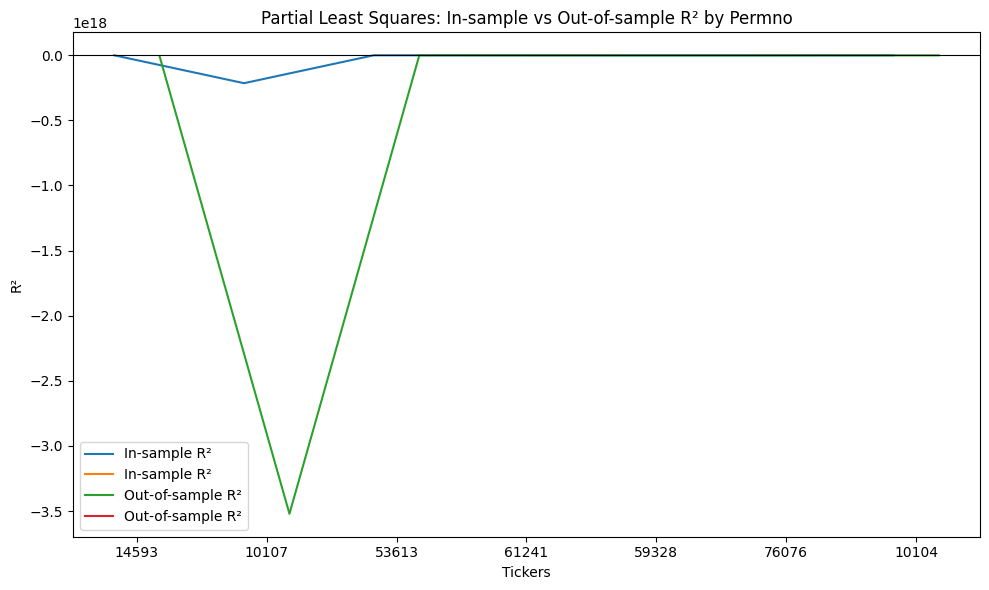

In [ ]:
# plot for PLS in-sample vs out-of_sample R^2:
labels = [str(p) for p in PERMNOS]
in_vals = [r2_in_pls[p] for p in PERMNOS]
out_vals = [r2_out_pls[p] for p in PERMNOS]

x = np.arange(len(PERMNOS))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x - width/2, in_vals, width, label='In-sample R²')
ax.plot(x + width/2, out_vals, width, label='Out-of-sample R²')

ax.set_xlabel('Tickers')
ax.set_ylabel('R²')
ax.set_title('Partial Least Squares: In-sample vs Out-of-sample R² by Permno')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Use PLS to include interaction terms, select predictors that are most strongly correlated to outputs, and use PLS to forecast y
# this part of the code takes about 25 mins to run
from sklearn.cross_decomposition import PLSRegression

X_train, y_train, X_test, y_test = {}, {}, {}, {}
y_pred_train, y_test_train, r2_in, r2_out = {}, {}, {}, {}

for p in PERMNOS:
  X_train[p] = df[(df['DATE']>= START_train) & (df['DATE'] <= END_train) & (df['permno'] == p)][char_cols]
  y_train[p] = return_train[p]

  X_test[p] = df[(df['DATE']>= START_test) & (df['DATE'] <= END_test) & (df['permno'] == p)][char_cols]
  y_test[p] = return_test[p]

  # Since PLS directly selects predictors based on forecasting y, we can include interaction terms in case some interactions are significant
  pls_pipe = Pipeline(
    [
     ('interactions', PolynomialFeatures(degree = 2, interaction_only=True, include_bias=False)),
     ('scaler', StandardScaler()), # standardising the variables comes after including interactions
     ('pls', PLSRegression())
    ]
  )

  param_grid = {"pls__n_components": range(1, df[char_cols].shape[1] + 1)} # maximum is to choose all predictors

  pls_grid = GridSearchCV(
      pls_pipe,
      param_grid,
      cv=10,
      scoring='r2',
      n_jobs=-1
  )
  pls_grid.fit(X_train[p], y_train[p])

  best_n_components = pls_grid.best_params_["pls__n_components"]
  print(f"Optimal number of principal components: {best_n_components}")

  # fit the final model with optimal number of components and print its R score
  best_pls = pls_grid.best_estimator_
  # make predictions
  y_pred_train[p] = best_pls.predict(X_train[p])
  y_pred_test[p] = best_pls.predict(X_test[p])

  # R^2 scores
  r2_in[p] = r2_oos(y_true = y_train[p], y_predict = y_pred_train[p])
  r2_out[p] = r2_oos(y_true = y_test[p], y_predict = y_pred_test[p])


In [ ]:
# plot for PLS in-sample vs out-of_sample R^2:
labels = [str(p) for p in PERMNOS]
in_vals = [r2_in[p] for p in PERMNOS]
out_vals = [r2_out[p] for p in PERMNOS]

x = np.arange(len(PERMNOS))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x - width/2, in_vals, width, label='In-sample R²')
ax.plot(x + width/2, out_vals, width, label='Out-of-sample R²')

ax.set_xlabel('Tickers')
ax.set_ylabel('R²')
ax.set_title('Partial Least Squares: In-sample vs Out-of-sample R² by Permno')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Use GAM to precit outputs

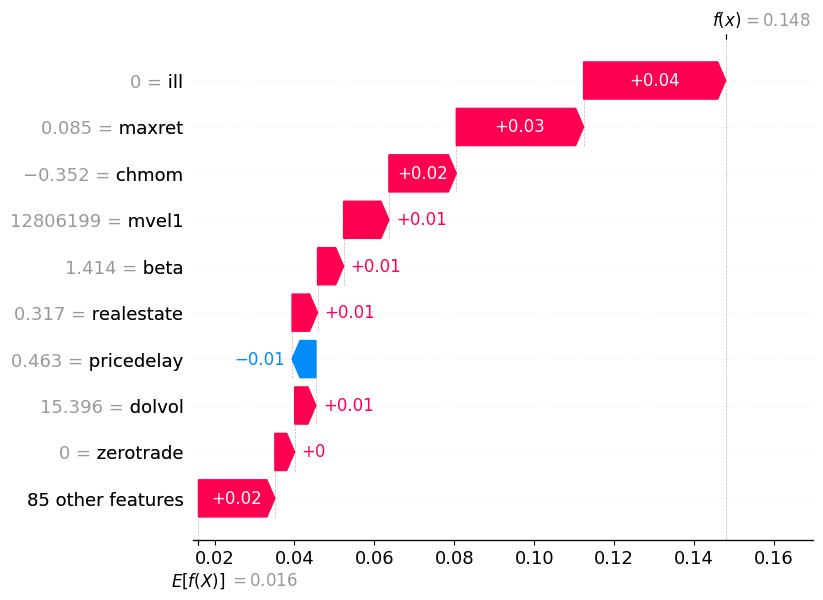

In [ ]:
# Moving on to the non-parametric method, use grandient boosting and random forest to predict return
# first visualise variable importance when using xgboost
import xgboost
import shap

X_train_test1 = X_train[10107]
y_train_test1 = y_train[10107]

xg_test1 = xgboost.XGBRegressor().fit(X_train_test1, y_train_test1)

# explain the model's predictions using SHAP
xg_explainer = shap.Explainer(xg_test1)
shap_values = xg_explainer(X_train_test1)

# visualize the first prediction's explanation
shap.plots.waterfall(shap_values[0])




Gradient boosted regression trees (GBRT) starts fitting a shallow tree (e.g., with depth L =1
⁠). This oversimplified tree is sure to be a weak predictor with large bias in the training sample. Next, a second simple tree (with the same shallow depth
⁠) is used to fit the prediction residuals from the first tree. Forecasts from these two trees are added together to form an ensemble prediction of the outcome, but the forecast component from the second tree is shrunken by a factor v (between 0-1)
 to help prevent the model from overfitting the residuals. At each new step b
⁠, a shallow tree is fitted to the residuals from the model with
 trees, and its residual forecast is added to the total with a shrinkage weight of
v⁠. This is iterated until there are a total of B
 trees in the ensemble. The final output is therefore an additive model of shallow trees with three tuning parameters
⁠, which we adaptively choose in the validation step.

In [ ]:
# Moving on to the non-parametric method, use a gradient boosting and random forest to
# rank variable importance and predict outputs
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# firstly use gradient boosted regression tress (GBRT)
X_train_gbr, y_train_gbr, X_test_gbr, y_test_gbr = {}, {}, {}, {}
y_pred_train_gbr, y_pred_test_gbr, r2_in_gbr, r2_out_gbr = {}, {}, {}, {}

for p in PERMNOS:
  X_train_gbr[p] = df[(df['DATE']>= START_train) & (df['DATE'] <= END_train) & (df['permno'] == p)][char_cols]
  y_train_gbr[p] = return_train[p]

  X_test_gbr[p] = df[(df['DATE']>= START_test) & (df['DATE'] <= END_test) & (df['permno'] == p)][char_cols]
  y_test_gbr[p] = return_test[p]

  param_grid = {
    'n_estimators': [100, 200, 300], # controls the number of boosting trees (B) built sequentially
    'learning_rate': [0.01, 0.02, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'min_samples_leaf': [5, 10],
    'subsample': [0.8, 1.0] # for stochastic gradient boosting, controls the fraction of training rows randomly sampled (without replacement) to build each individual trees
    }

  gbr = GradientBoostingRegressor(random_state = 42)

  grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
    )

  grid_search.fit(X_train_gbr[p], y_train_gbr[p])

  best_params = grid_search.best_params_
  print(f"Best parameters: {best_params}")

  # evaluate on test set
  best_gbr = grid_search.best_estimator_
  y_pred_train_gbr[p] = best_gbr.predict(X_train_gbr[p])
  y_pred_test_gbr[p] = best_gbr.predict(X_test_gbr[p])

  # R^2 scores
  r2_in_gbr[p] = r2_oos(y_true = y_train[p], y_predict = y_pred_train_gbr[p])
  r2_out_gbr[p] = r2_oos(y_true = y_test[p], y_predict = y_pred_test_gbr[p])





Like boosting, a random forest is an ensemble method that combines forecasts from many different trees. It is a variation on a more general procedure known as bootstrap aggregation, or “bagging”. The baseline tree bagging procedure draws
 different bootstrap samples of the data, fits a separate regression tree to each, then averages their forecasts. Trees for individual bootstrap samples tend to be deep and overfit, making their individual predictions inefficiently variable. Averaging over multiple predictions reduces this variation, thus stabilizing the trees’ predictive performance.

In [ ]:
# Use random forest to predict the retur
from sklearn.ensemble import RandomForestRegressor

# random forest without tuning hyperparameters:
X_train_rf, y_train_rf, X_test_rf, y_test_rf = {}, {}, {}, {}
y_pred_train_rf, y_pred_test_rf, r2_in_rf, r2_out_rf = {}, {}, {}, {}

for p in PERMNOS:
  X_train_rf[p] = df[(df['DATE']>= START_train) & (df['DATE'] <= END_train) & (df['permno'] == p)][char_cols]
  y_train_rf[p] = return_train[p]

  X_test_rf[p] = df[(df['DATE']>= START_test) & (df['DATE'] <= END_test) & (df['permno'] == p)][char_cols]
  y_test_rf[p] = return_test[p]

  rf = RandomForestRegressor(
    n_estimators = 500, # controls the number of boosting trees (B) built
    max_depth = None, # the max number of branches to have
    min_samples_leaf = 5, # min samples to be in one leaf
    max_features = 'sqrt', # the number of features to consider when looking for best split, 'sqrt' then max features = sqrt(n_features)
    random_state = 42,
    n_jobs = -1
  )

  rf.fit(X_train_rf[p], y_train_rf[p])

  best_estimators = rf.estimators_
  print(f"Best parameters: {best_estimators}")

  # evaluate on test set
  y_pred_train_rf[p] = rf.predict(X_train_rf[p])
  y_pred_test_rf[p] = rf.predict(X_test_rf[p])

  # R^2 scores
  r2_in_rf[p] = r2_oos(y_true = y_train[p], y_predict = y_pred_train_rf[p])
  r2_out_rf[p] = r2_oos(y_true = y_test[p], y_predict = y_pred_test_rf[p])


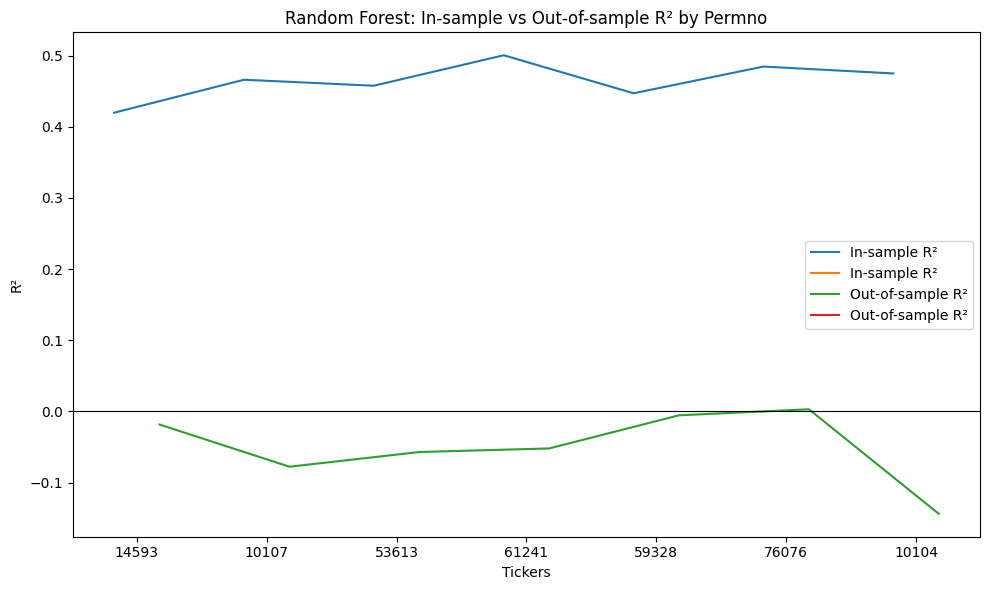

In [ ]:
# plot for random forest in-sample vs out-of_sample R^2:
labels = [str(p) for p in PERMNOS]
in_vals = [r2_in_rf[p] for p in PERMNOS]
out_vals = [r2_out_rf[p] for p in PERMNOS]

x = np.arange(len(PERMNOS))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x - width/2, in_vals, width, label='In-sample R²')
ax.plot(x + width/2, out_vals, width, label='Out-of-sample R²')

ax.set_xlabel('Tickers')
ax.set_ylabel('R²')
ax.set_title('Random Forest: In-sample vs Out-of-sample R² by Permno')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

Our analysis focuses on traditional “feed-forward” networks. These consist of an “input layer” of raw predictors, one or more “hidden layers” that interact and nonlinearly transform the predictors, and an “output layer” that aggregates hidden layers into an ultimate outcome prediction. Analogous to axons in a biological brain, layers of the networks represent groups of “neurons” with each layer connected by “synapses” that transmit signals among neurons of different layers.

There are many potential choices for the nonlinear activation function (such as sigmoid, hyperbolic, softmax). We use the same activation function at all nodes, and choose a popular functional form in recent literature known as the rectified linear unit (ReLU), which encourages sparsity in the number of active neurons and allows for faster derivative evaluation.

In [ ]:
# Use "feed-forward" Neural Network to forecast returns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# start with NN with a single hidden layer consisting 16 neurons
X_train_nn1, y_train_nn1, X_test_nn1, y_test_nn1 = {}, {}, {}, {}
y_pred_train_nn1, y_pred_test_nn1, r2_in_nn1, r2_out_nn1 = {}, {}, {}, {}

for p in PERMNOS:
  X_train_nn1[p] = df[(df['DATE']>= START_train) & (df['DATE'] <= END_train) & (df['permno'] == p)][char_cols]
  y_train_nn1[p] = return_train[p]

  X_test_nn1[p] = df[(df['DATE']>= START_test) & (df['DATE'] <= END_test) & (df['permno'] == p)][char_cols]
  y_test_nn1[p] = return_test[p]

  model = keras.Sequential(
      [
          layers.Input(shape=(X_train_nn1[p].shape[1],)),
          layers.Dense(16, activation="relu"),
          layers.BatchNormalization(),
          layers.Dense(1)
      ]
  )

  # compile the model using Adam optimiser, stochastic gradient descent, using mse as loss function
  model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
                loss='mse',
                metrics=['mae', tf.keras.metrics.R2Score(), 'mse'])

  # apply early stopping to the model
  early_stopping = keras.callbacks.EarlyStopping(
      monitor='val_loss',
      patience=10,
      min_delta=1e-4,
      restore_best_weights=True
  )

  model.fit(X_train_nn1[p],
            y_train_nn1[p],
            validation_split=0.2, # use 20% data as the validation set
            epochs=300,
            batch_size=32,
            shuffle=True,
            callbacks=[early_stopping],
            verbose=0
            )
  # evaluate on test set
  y_pred_train_nn1[p] = model.predict(X_train_nn1[p]).flatten()
  y_pred_test_nn1[p] = model.predict(X_test_nn1[p]).flatten()

  # R^2 scores
  r2_in_nn1[p] = r2_oos(y_true = y_train_nn1[p], y_predict = y_pred_train_nn1[p])
  r2_out_nn1[p] = r2_oos(y_true = y_test_nn1[p], y_predict = y_pred_test_nn1[p])

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


We estimate the neural network weight parameters by minimizing the penalized
 objective function of prediction errors. Unlike tree-based algorithms that require “greedy” optimization, training a neural network, in principle, allows for joint updates of all model parameters at each step of the optimization—a substantial advantage of neural networks over trees.

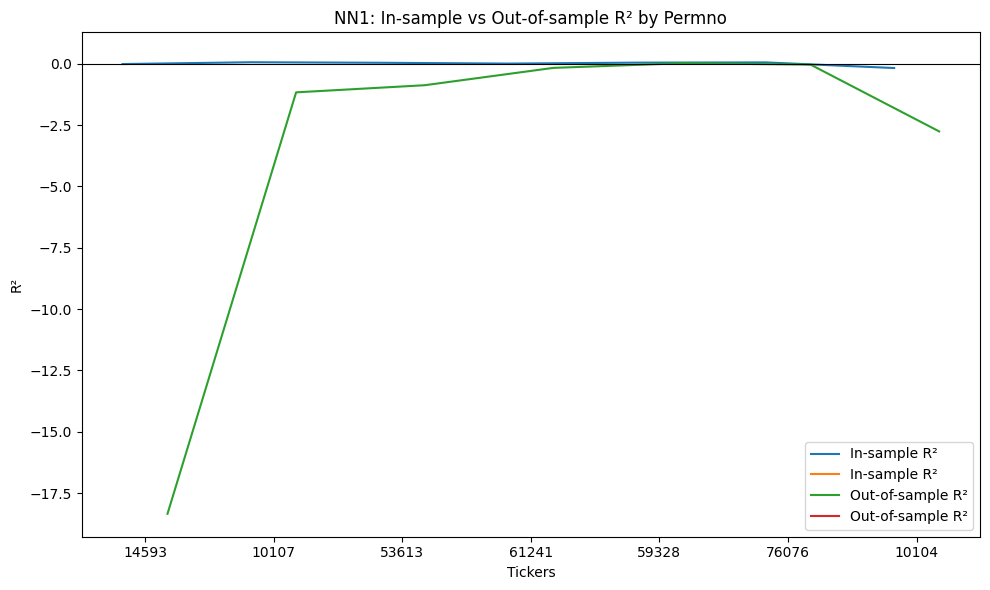

In [ ]:
# plot for random forest in-sample vs out-of_sample R^2:
labels = [str(p) for p in PERMNOS]
in_vals = [r2_in_nn1[p] for p in PERMNOS]
out_vals = [r2_out_nn1[p] for p in PERMNOS]

x = np.arange(len(PERMNOS))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x - width/2, in_vals, width, label='In-sample R²')
ax.plot(x + width/2, out_vals, width, label='Out-of-sample R²')

ax.set_xlabel('Tickers')
ax.set_ylabel('R²')
ax.set_title('NN1: In-sample vs Out-of-sample R² by Permno')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# moving on to NN with 3 hidden layers consisting geometrically decreasing neurons
X_train_nn3, y_train_nn3, X_test_nn3, y_test_nn3 = {}, {}, {}, {}
y_pred_train_nn3, y_pred_test_nn3, r2_in_nn3, r2_out_nn3 = {}, {}, {}, {}

for p in PERMNOS:
  X_train_nn3[p] = df[(df['DATE']>= START_train) & (df['DATE'] <= END_train) & (df['permno'] == p)][char_cols]
  y_train_nn3[p] = return_train[p]

  X_test_nn3[p] = df[(df['DATE']>= START_test) & (df['DATE'] <= END_test) & (df['permno'] == p)][char_cols]
  y_test_nn3[p] = return_test[p]

  model = keras.Sequential(
      [
          layers.Input(shape=(X_train_nn3[p].shape[1],)),
          layers.Dense(16),
          layers.BatchNormalization(),
          layers.Activation("relu"),
          layers.Dense(8),
          layers.BatchNormalization(),
          layers.Activation("relu"),
          layers.Dense(4),
          layers.BatchNormalization(),
          layers.Activation("relu"),
          layers.Dense(1)
      ]
  )

  # compile the model using Adam optimiser, stochastic gradient descent, using mse as loss function
  model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
                loss='mse',
                metrics=['mae', tf.keras.metrics.R2Score(), 'mse'])

  # apply early stopping to the model
  early_stopping = keras.callbacks.EarlyStopping(
      monitor='val_loss',
      patience=10,
      min_delta=1e-4,
      restore_best_weights=True
  )

  model.fit(X_train_nn3[p],
            y_train_nn3[p],
            validation_split=0.2, # use 20% data as the validation set
            epochs=300,
            batch_size=32,
            shuffle=True,
            callbacks=[early_stopping],
            verbose=0
            )
  # evaluate on test set
  y_pred_train_nn3[p] = model.predict(X_train_nn3[p]).flatten()
  y_pred_test_nn3[p] = model.predict(X_test_nn3[p]).flatten()

  # R^2 scores
  r2_in_nn3[p] = r2_oos(y_true = y_train_nn3[p], y_predict = y_pred_train_nn3[p])
  r2_out_nn3[p] = r2_oos(y_true = y_test_nn3[p], y_predict = y_pred_test_nn3[p])

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


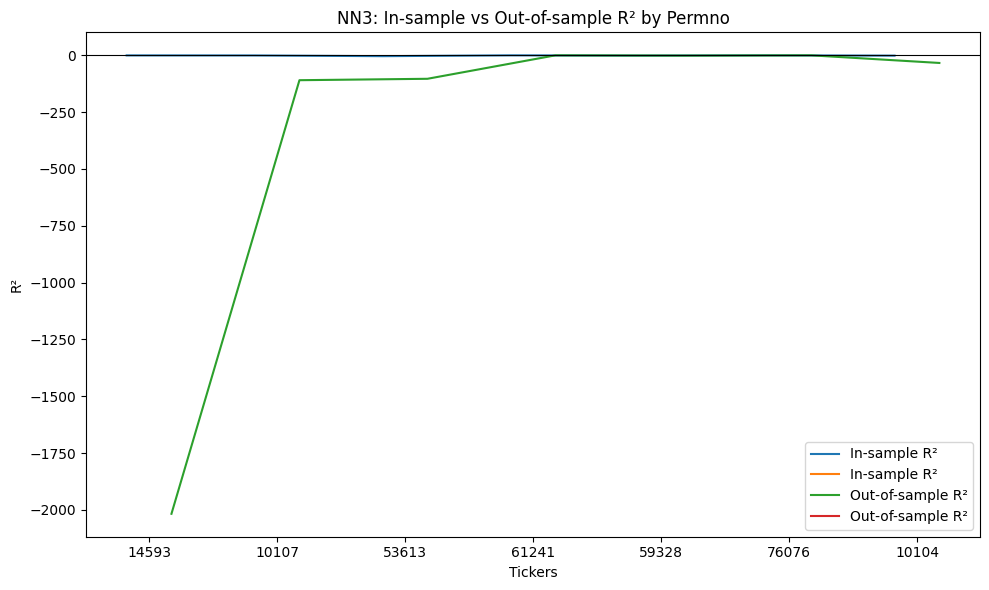

In [ ]:
# plot for random forest in-sample vs out-of_sample R^2:
labels = [str(p) for p in PERMNOS]
in_vals = [r2_in_nn3[p] for p in PERMNOS]
out_vals = [r2_out_nn3[p] for p in PERMNOS]

x = np.arange(len(PERMNOS))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x - width/2, in_vals, width, label='In-sample R²')
ax.plot(x + width/2, out_vals, width, label='Out-of-sample R²')

ax.set_xlabel('Tickers')
ax.set_ylabel('R²')
ax.set_title('NN3: In-sample vs Out-of-sample R² by Permno')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

# extreme overfitting resulted in very negative R^2